<div style="text-align:center;">

# Actividad 5 | Visualización de Resultados

### Validación cruzada *k*-fold y visualización del mejor modelo

**Tecnológico de Monterrey**
**Maestría en Inteligencia Artificial Aplicada**
**TC4034 — Análisis de Grandes Volúmenes de Datos · Módulo 6 (Semanas 9 y 10)**

**Caso de estudio:** NYC TLC *Yellow Taxi Trip Records* 2024

**Entregable:** Visualización_Equipo61 · **Modalidad:** En equipo

**Integrantes — Equipo 61**
Eduardo Ramos Hernández — A01797393
Diana Gabriela Ramírez Moreno — A01630769
Oscar Ramírez Anaya — A01795438
Emmanuel Francisco Ramírez Hernández — A01796289

**Profesor:** Dr. Iván Olmos Pineda
**Fecha de entrega:** 21 de junio de 2026

</div>

---

> **Nota de cómputo.** Este cuaderno se ejecuta sobre **Apache Spark (PySpark MLlib)** en modo local
> (`local[*]`). El mismo pipeline escala sin cambios a un clúster **GCP Dataproc** leyendo la base global
> completa desde Cloud Storage (`gs://…`). El parámetro `MESES` controla cuántos meses de 2024 se
> procesan localmente (por defecto los **12**); la metodología es idéntica a cualquier escala.

## Contexto y objetivo

Esta actividad pertenece al curso *Análisis de Grandes Volúmenes de Datos*. El *Big Data* se caracteriza
por las **V**: **Volumen**, **Velocidad**, **Variedad**, **Veracidad** y **Valor**. Sobre los **viajes en
taxi amarillo de Nueva York (NYC TLC) 2024** se retoma el mejor modelo de la **Actividad 4** —un
`RandomForestClassifier` que predice si un viaje deja **propina alta** (`tip_alta`)— y se responde una
pregunta que una sola partición *train/test* **no** puede contestar: **¿cuánta variabilidad** tienen sus
métricas y **qué tan bien generaliza**.

La herramienta para ello es la **validación cruzada *k*-fold estratificada**: se entrena y evalúa el
modelo *k* veces sobre particiones disjuntas y representativas, y se **comunican los resultados con
visualizaciones** (gráficas por pliegue, curvas ROC y PR, mapas de calor, calibración, distribuciones y
estadísticas de variabilidad).

**Continuidad.** Se reutilizan las **variables de caracterización** (`tipo_dia × zona_origen × tipo_pago`
→ **12 estratos**) y la **estrategia de muestreo estratificado** del Módulo 3, y la **muestra M** y el
**mejor modelo** de la Actividad 4. La tarea supervisada se restringe a viajes con **tarjeta** (la propina
solo se captura electrónicamente).

### Estructura del cuaderno

- **§0 Preparación** — entorno, datos, capa Silver, 12 estratos y reconstrucción de la muestra **M**.
- **§1 Definición de la validación cruzada** — elección y argumentación del valor ***k***.
- **§2 Construcción de los *k*-folds** — poblado **estratificado y determinista** de cada pliegue.
- **§3 Experimentacion** — entrenamiento del mejor modelo por pliegue y registro de métricas.
- **§4 Resultados** — visualización y lectura de la variabilidad y la generalización.
- **§5 Discusión y conclusiones** — significancia de los resultados para la tarea planteada.

## 0. Preparación: entorno, datos y reconstrucción de la muestra M

Antes de las cinco secciones de la rúbrica se reconstruye el flujo validado en las Actividades 3 y 4
(entorno PySpark, ingesta 2024, capa Silver, los 12 estratos del Módulo 3 y la muestra **M** del paso 1
de la Actividad 4). Esto hace el cuaderno **autocontenido y reproducible**.

### 0.1 Entorno PySpark local

In [1]:
import os, glob, math, random, time
from functools import reduce

# Java 17 (Homebrew) para el runtime de Spark
os.environ.setdefault("JAVA_HOME",
    "/opt/homebrew/Cellar/openjdk@17/17.0.17/libexec/openjdk.jdk/Contents/Home")

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import numpy as np
import pandas as pd

spark = (SparkSession.builder
         .master("local[*]")
         .appName("M6_Act5_VisualizacionResultados_Equipo61")
         .config("spark.sql.parquet.mergeSchema", "false")
         .config("spark.sql.adaptive.enabled", "true")
         .config("spark.driver.memory", "6g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print("PySpark", spark.version, "| semilla global SEED =", SEED)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/21 11:16:36 WARN Utils: Your hostname, MacBook-Pro-de-Oscar.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.47 instead (on interface en0)
26/06/21 11:16:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/21 11:16:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark 4.1.1 | semilla global SEED = 42


### 0.2 Ingesta del dataset 2024 y esquema canónico

Los Parquet oficiales de 2024 presentan **heterogeneidad de tipos** entre meses (`RatecodeID`,
`passenger_count`, `congestion_surcharge`, `airport_fee` oscilan INT64/DOUBLE). Se **normaliza** cada
archivo a un **esquema canónico** y se unen con `unionByName`. El parámetro `MESES` (variable de entorno
o lista) decide cuántos meses se procesan: por defecto **todos los disponibles localmente** (los 12).

In [2]:
# Esquema canonico (resuelve la heterogeneidad INT64/DOUBLE entre meses de 2024)
TARGET_TYPES = {
    "VendorID":"bigint", "tpep_pickup_datetime":"timestamp", "tpep_dropoff_datetime":"timestamp",
    "passenger_count":"double", "trip_distance":"double", "RatecodeID":"double",
    "store_and_fwd_flag":"string", "PULocationID":"bigint", "DOLocationID":"bigint",
    "payment_type":"bigint", "fare_amount":"double", "extra":"double", "mta_tax":"double",
    "tip_amount":"double", "tolls_amount":"double", "improvement_surcharge":"double",
    "total_amount":"double", "congestion_surcharge":"double", "airport_fee":"double",
}

# Localiza los Parquet (carpeta local de esta actividad o, como respaldo, la de la Actividad 3)
CARPETAS = ["data/yellow_2024",
            "../actividad_3_aprendizaje_supervisado/data/yellow_2024"]
CARPETA = next((c for c in CARPETAS if glob.glob(c + "/yellow_tripdata_2024-*.parquet")), CARPETAS[0])
archivos = sorted(glob.glob(CARPETA + "/yellow_tripdata_2024-*.parquet"))
print(f"Carpeta de datos: {CARPETA}  |  archivos encontrados: {len(archivos)}")

def leer_y_normalizar(path):
    d = spark.read.parquet(path)
    exprs = []
    for col_name, tipo in TARGET_TYPES.items():
        if col_name in d.columns:
            exprs.append(F.col(col_name).cast(tipo).alias(col_name))
        else:
            exprs.append(F.lit(None).cast(tipo).alias(col_name))
    return d.select(*exprs)

df = reduce(lambda a, b: a.unionByName(b), [leer_y_normalizar(p) for p in archivos]).cache()
TOTAL = df.count()
print(f"Base global D (local, {len(archivos)} meses): {TOTAL:,} registros crudos")

Carpeta de datos: data/yellow_2024  |  archivos encontrados: 12


Base global D (local, 12 meses): 41,169,720 registros crudos


### 0.3 Capa Silver y los 12 estratos del Módulo 3

Se aplican los **filtros de calidad** de la Actividad 3 (tarifas y distancias positivas, distancia
< 200 mi, orden temporal correcto, tarifa válida, claves no nulas, año 2024) y se generan las tres
**variables de caracterización** que definen los estratos: `tipo_dia × zona_origen × tipo_pago`.

In [3]:
df_silver = (df
    .filter(F.col("fare_amount") > 0)
    .filter(F.col("trip_distance") > 0)
    .filter(F.col("trip_distance") < 200)
    .filter(F.col("tpep_pickup_datetime") < F.col("tpep_dropoff_datetime"))
    .filter((F.col("RatecodeID").isNull()) | (F.col("RatecodeID") != 99))
    .filter(F.col("PULocationID").isNotNull())
    .filter(F.col("payment_type").isNotNull())
    .filter(F.year("tpep_pickup_datetime") == 2024))
N_SILVER = df_silver.count()
print(f"Capa Silver: {N_SILVER:,} registros  ({(1-N_SILVER/TOTAL)*100:.2f}% descartado)")

Capa Silver: 39,263,800 registros  (4.63% descartado)


In [4]:
# Zonas TLC (IDs oficiales) para la variable zona_origen
manhattan_ids = [4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90,
                 100, 103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140,
                 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166,
                 170, 186, 194, 202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236,
                 237, 238, 239, 243, 244, 246, 249, 261, 262, 263]
aeropuerto_ids = [1, 132, 138]   # Newark, JFK, LaGuardia

df_part = (df_silver
    .withColumn("tipo_dia",
        F.when(F.dayofweek("tpep_pickup_datetime").isin([1, 7]), "Finde").otherwise("Laborable"))
    .withColumn("zona_origen",
        F.when(F.col("PULocationID").isin(aeropuerto_ids), "Aeropuerto")
         .when(F.col("PULocationID").isin(manhattan_ids),  "Manhattan").otherwise("Otros"))
    .withColumn("tipo_pago",
        F.when(F.col("payment_type") == 1, "Tarjeta").otherwise("NoTarjeta"))
    .withColumn("particion_id",
        F.concat_ws("|", F.col("tipo_dia"), F.col("zona_origen"), F.col("tipo_pago")))).cache()
part_counts = {r["particion_id"]: r["count"]
               for r in df_part.groupBy("particion_id").count().collect()}
print(f"Estratos reconstruidos: {len(part_counts)}")
for pid, c in sorted(part_counts.items(), key=lambda x: -x[1]):
    print(f"  {pid:32s} {c:>12,}")

Estratos reconstruidos: 12
  Laborable|Manhattan|Tarjeta        19,598,574
  Finde|Manhattan|Tarjeta             7,245,038
  Laborable|Manhattan|NoTarjeta       5,728,077
  Finde|Manhattan|NoTarjeta           2,561,052
  Laborable|Aeropuerto|Tarjeta        1,812,249
  Finde|Aeropuerto|Tarjeta              673,092
  Laborable|Aeropuerto|NoTarjeta        473,365
  Laborable|Otros|NoTarjeta             329,857
  Laborable|Otros|Tarjeta               290,836
  Finde|Otros|NoTarjeta                 248,146
  Finde|Aeropuerto|NoTarjeta            175,537
  Finde|Otros|Tarjeta                   127,977


### 0.4 Reconstrucción de la muestra M (paso 1 de la Actividad 4)

Se reconstruye **M** con el criterio de la Actividad 4: tamaño justificado por **Cochran (1977)** con
**corrección por población finita (FPC)**, **asignación proporcional** por estrato con un **piso** de
salvaguarda, y **muestreo sistemático intra-estrato** ordenado por `tpep_pickup_datetime` (técnica del
Módulo 3). Sobre M se derivan las variables de modelado y la etiqueta `tip_alta`.

In [5]:
# Tamano de muestra (Cochran + FPC): p=0.5 (varianza maxima), z=1.96 (95%), e=0.01 (+/-1%)
Z, p_var, e = 1.96, 0.5, 0.01
n0    = (Z**2 * p_var * (1 - p_var)) / (e**2)
n_min = math.ceil(n0 / (1 + (n0 - 1) / N_SILVER))
N_MUESTRA = 80_000
print(f"n minimo (FPC, 95%, +/-1%) = {n_min:,}   |   n de trabajo M = {N_MUESTRA:,}")

# Asignacion proporcional por estrato con piso de salvaguarda
PISO = 200
cuotas = {pid: min(cnt, max(PISO, math.ceil(N_MUESTRA * cnt / N_SILVER)))
          for pid, cnt in part_counts.items()}

# Muestreo sistematico intra-estrato ordenado por fecha de pickup (reproducible)
w = Window.partitionBy("particion_id").orderBy("tpep_pickup_datetime")
df_rn = df_part.withColumn("rn", F.row_number().over(w))
saltos    = {pid: max(1, part_counts[pid] // cuotas[pid]) for pid in part_counts}
arranques = {pid: random.randint(0, saltos[pid] - 1)      for pid in part_counts}
cond = F.lit(False)
for pid in part_counts:
    k_step, r0, ni = saltos[pid], arranques[pid], cuotas[pid]
    cond = cond | ((F.col("particion_id") == pid) &
        (((F.col("rn") - F.lit(1 + r0)) % F.lit(k_step)) == 0) &
        (F.col("rn") <= F.lit(r0 + 1 + k_step * (ni - 1))))
M = df_rn.filter(cond).drop("rn").cache()
print(f"Tamano de la muestra M: {M.count():,} registros")

n minimo (FPC, 95%, +/-1%) = 9,602   |   n de trabajo M = 80,000


Tamano de la muestra M: 80,006 registros


In [6]:
# Variables derivadas, imputacion, tope de propina (P99) y etiqueta binaria tip_alta
M2 = (M
    .withColumn("trip_duration_min",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60.0)
    .withColumn("pickup_hour",  F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_dow",   F.dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_month", F.month("tpep_pickup_datetime"))
    .fillna({"passenger_count": 1, "congestion_surcharge": 0.0, "airport_fee": 0.0})
    .filter(F.col("trip_duration_min") > 0)
    .filter(F.col("trip_duration_min") < 180))
p99 = M2.approxQuantile("tip_amount", [0.99], 0.01)[0]
M2 = (M2.withColumn("tip_amount", F.when(F.col("tip_amount") > p99, p99).otherwise(F.col("tip_amount")))
        .withColumn("tip_alta", F.when(F.col("tip_amount") / F.col("fare_amount") > 0.20, 1).otherwise(0)))

# Tarea supervisada: SOLO tarjeta (la propina solo se captura electronicamente con tarjeta)
sup = M2.filter(F.col("tipo_pago") == "Tarjeta").cache()
df_part.unpersist()
N_SUP = sup.count()
print(f"Poblacion supervisada (solo tarjeta) en M: {N_SUP:,} registros")
sup.groupBy("tip_alta").count().orderBy("tip_alta").show()

Poblacion supervisada (solo tarjeta) en M: 60,574 registros
+--------+-----+
|tip_alta|count|
+--------+-----+
|       0|14648|
|       1|45926|
+--------+-----+



## 1. Definición del proceso de validación cruzada

### 1.1 Objetivo de la validación cruzada en este proyecto

La Actividad 4 identificó al `RandomForestClassifier` (restringido a tarjeta) como el **mejor modelo** y
estableció **AUC-ROC** y **AUC-PR** como métricas principales de calidad. Lo que **una sola partición
*train/test* no mide** es la **variabilidad** de esas métricas: una estimación puntual puede ser
optimista o pesimista por azar de la partición. La **validación cruzada *k*-fold** responde a eso:
entrena y evalúa el modelo *k* veces sobre particiones disjuntas, produciendo una **distribución** de
cada métrica (media ± desviación) y permitiendo **detectar sobre-ajuste** comparando train vs. test en
cada pliegue.

### 1.2 Elección y argumentación del valor *k*

Se elige **k = 5**. La decisión es **multidimensional**, no arbitraria:

1. **Sesgo–varianza del estimador de CV (Kohavi, 1995).** Con *k* pequeño (p. ej. 2–3) cada modelo ve
   pocos datos → estimación **sesgada (pesimista)**. Con *k* grande (p. ej. *leave-one-out*) los conjuntos
   de entrenamiento se solapan casi por completo → estimación de **alta varianza** y costo enorme.
   **k = 5** (entrena con el 80 % y evalúa con el 20 % en cada vuelta) es el punto de equilibrio
   recomendado en la literatura.
2. **Representatividad por pliegue.** No basta con *k*: la **estratificación** por
   `particion_id × tip_alta` garantiza que cada pliegue reproduzca la composición de la población (§2).
   Con *k = 5* incluso el **estrato más pequeño** conserva suficientes instancias por pliegue; con *k = 10*
   se reduciría a la mitad, elevando el riesgo de pliegues no representativos (se verifica numéricamente
   abajo).
3. **Costo computacional en Big Data (Junqué de Fortuny et al., 2013).** Cada pliegue adicional es **un
   entrenamiento completo más** sobre grandes volúmenes. *k = 5* realiza **5** entrenamientos frente a
   **10** de *k = 10*, reduciendo a la mitad el costo **sin** pérdida proporcional de precisión del
   estimador.

> **Alternativas consideradas.** *k = 3* es más económico pero más sesgado; *k = 10* y la **validación
> cruzada repetida** (*repeated k-fold*) reducen varianza a mayor costo. Para una población de decenas de
> millones de registros, **k = 5** ofrece el mejor compromiso *sesgo–varianza–costo*. La tabla siguiente
> resume el trade-off.

In [7]:
# Comparativa del trade-off entre valores de k (entrenamientos, % train por pliegue, instancias minimas)
sup_counts = {r["particion_id"]: r["count"]
              for r in sup.groupBy("particion_id").count().collect()}
min_pid = min(sup_counts, key=sup_counts.get)
n_min_estrato = sup_counts[min_pid]

tabla_k = pd.DataFrame([
    {"k": k,
     "entrenamientos": k,
     "% train por pliegue": round(100*(k-1)/k, 1),
     "instancias del estrato mas pequeno por pliegue": n_min_estrato // k,
     "perfil": {3: "mas sesgo, mas barato",
                5: "equilibrio (elegido)",
                10: "menos sesgo, mas costo/varianza"}[k]}
    for k in [3, 5, 10]])
print(f"Estrato de tarjeta mas pequeno: '{min_pid}' con {n_min_estrato:,} registros\n")
print(tabla_k.to_string(index=False))

K = 5
print(f"\nValor elegido: k = {K}")

Estrato de tarjeta mas pequeno: 'Finde|Otros|Tarjeta' con 259 registros

 k  entrenamientos  % train por pliegue  instancias del estrato mas pequeno por pliegue                          perfil
 3               3                 66.7                                              86           mas sesgo, mas barato
 5               5                 80.0                                              51            equilibrio (elegido)
10              10                 90.0                                              25 menos sesgo, mas costo/varianza

Valor elegido: k = 5


## 2. Construcción de los *k*-folds

Cada pliegue se construye con un reparto **estratificado y determinista** que reproduce la técnica del
Módulo 3 (estratificación + asignación sistemática intra-estrato):

1. La **llave de estrato** es `particion_id × tip_alta` (las particiones de caracterización dentro de
   tarjeta, cruzadas con la clase objetivo), de modo que cada pliegue conserve tanto la mezcla de estratos
   como el **balance de clases**.
2. Dentro de cada estrato, las instancias se ordenan por una **llave hash determinista**
   (`xxhash64` del contenido del viaje + semilla) y se asigna el pliegue con `row_number() % k`. A
   diferencia de `rand()`, esto es **100 % reproducible** entre ejecuciones, incluso en `local[*]` con
   múltiples particiones.
3. Se **verifica** que los pliegues sean **disjuntos y exhaustivos**, de tamaño equilibrado y
   representativos en clase y en composición de estratos.

In [8]:
# Asignacion ESTRATIFICADA y DETERMINISTA del numero de pliegue (reproducible, sin rand())
hash_key = F.xxhash64(
    F.col("tpep_pickup_datetime").cast("string"),
    F.col("PULocationID").cast("string"),
    F.col("DOLocationID").cast("string"),
    F.col("fare_amount").cast("string"),
    F.col("trip_distance").cast("string"),
    F.lit(SEED))
wf = Window.partitionBy("particion_id", "tip_alta").orderBy(hash_key)
sup_folds = (sup
    .withColumn("fold", (F.row_number().over(wf) % F.lit(K)).cast("int"))
    .repartition(8)
    .cache())
N_FOLDS_TOTAL = sup_folds.count()

print("Tamano de cada pliegue:")
sup_folds.groupBy("fold").count().orderBy("fold").show()

Tamano de cada pliegue:
+----+-----+
|fold|count|
+----+-----+
|   0|12109|
|   1|12120|
|   2|12118|
|   3|12114|
|   4|12113|
+----+-----+



In [9]:
# Verificacion 1: pliegues DISJUNTOS y EXHAUSTIVOS
suma_folds = sup_folds.groupBy("fold").count().agg(F.sum("count")).first()[0]
valores_fold = [r["fold"] for r in sup_folds.select("fold").distinct().collect()]
assert suma_folds == N_SUP == N_FOLDS_TOTAL, "La union de pliegues no reconstruye la poblacion"
assert sorted(valores_fold) == list(range(K)), "Hay numeros de pliegue fuera de 0..k-1"
print(f"OK: {K} pliegues disjuntos y exhaustivos | suma = {suma_folds:,} = |poblacion| = {N_SUP:,}")

# Verificacion 2: balance de la clase tip_alta por pliegue (debe ser ~constante)
print("\nProporcion de tip_alta=1 por pliegue (estratificacion en clase):")
(sup_folds.groupBy("fold")
    .agg(F.round(F.avg("tip_alta"), 4).alias("prop_tip_alta_1"), F.count("*").alias("n"))
    .orderBy("fold").show())

OK: 5 pliegues disjuntos y exhaustivos | suma = 60,574 = |poblacion| = 60,574

Proporcion de tip_alta=1 por pliegue (estratificacion en clase):
+----+---------------+-----+
|fold|prop_tip_alta_1|    n|
+----+---------------+-----+
|   0|         0.7584|12109|
|   1|         0.7581|12120|
|   2|         0.7581|12118|
|   3|         0.7581|12114|
|   4|         0.7582|12113|
+----+---------------+-----+



In [10]:
# Verificacion 3: composicion (%) de cada pliegue por estrato de caracterizacion
piv = (sup_folds.groupBy("particion_id", "fold").count()
       .groupBy("particion_id").pivot("fold").sum("count").fillna(0).toPandas()
       .set_index("particion_id").sort_index())
piv_pct = (piv.div(piv.sum(axis=0), axis=1) * 100).round(2)
print("Composicion (%) de cada pliegue por estrato (cada columna ~ identica => estratificacion correcta):")
print(piv_pct.to_string())

Composicion (%) de cada pliegue por estrato (cada columna ~ identica => estratificacion correcta):
                                  0      1      2      3      4
particion_id                                                   
Finde|Aeropuerto|Tarjeta       2.25   2.27   2.27   2.26   2.26
Finde|Manhattan|Tarjeta       24.36  24.36  24.35  24.36  24.35
Finde|Otros|Tarjeta            0.42   0.43   0.43   0.43   0.43
Laborable|Aeropuerto|Tarjeta   6.09   6.10   6.10   6.08   6.08
Laborable|Manhattan|Tarjeta   65.91  65.87  65.87  65.88  65.89
Laborable|Otros|Tarjeta        0.97   0.98   0.98   0.98   0.98


## 3. Experimentacion

Se entrena el **mejor algoritmo de la Actividad 4** —`RandomForestClassifier` (`numTrees=50`,
`maxDepth=8`)— bajo el esquema de validación cruzada de 5 pliegues. Para cada pliegue *f*:

- **Entrenamiento** con los 4 pliegues restantes (`fold != f`) y **prueba** con el retenido (`fold == f`).
- Se registran las métricas establecidas como mejores en la Actividad 4 —**AUC-ROC** y **AUC-PR**
  (calculadas de forma **distribuida** en `pyspark.ml`)— y, además, métricas **binarias por clase**
  (precisión, *recall*, F1 de la clase positiva `tip_alta=1`), **MCC** y **Balanced Accuracy**, más
  robustas que las *weighted* bajo desbalance.
- Se mide la **brecha train–test** (AUC) para detectar **sobre-ajuste** y el **tiempo** por pliegue.
- Se guardan las **predicciones** (probabilidad, etiqueta, predicción) y la **importancia de variables**.

**Prevención de fuga de datos.** Se excluyen de las características `payment_type` (origen de la
estratificación), `tip_amount` y `total_amount` (delatan la propina).

In [11]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Pipeline: categoricas (sin tipo_pago) + numericas (sin tip_amount ni total_amount)
cat_cols = ["zona_origen", "tipo_dia"]
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]
num_cols = ["trip_distance", "trip_duration_min", "fare_amount", "tolls_amount",
            "congestion_surcharge", "airport_fee", "passenger_count",
            "pickup_hour", "pickup_dow", "pickup_month"]
assembler = VectorAssembler(inputCols=num_cols + [c+"_ohe" for c in cat_cols],
                            outputCol="features", handleInvalid="skip")

def make_pipeline():
    rf = RandomForestClassifier(featuresCol="features", labelCol="tip_alta",
                                numTrees=50, maxDepth=8, seed=SEED)
    return Pipeline(stages=indexers + encoders + [assembler, rf])

# Evaluadores AUC (calculo distribuido y escalable en pyspark.ml)
ev_auc = BinaryClassificationEvaluator(labelCol="tip_alta", rawPredictionCol="rawPrediction",
                                       metricName="areaUnderROC")
ev_pr  = BinaryClassificationEvaluator(labelCol="tip_alta", rawPredictionCol="rawPrediction",
                                       metricName="areaUnderPR")

def binarias_desde_pandas(y, yhat):
    # Metricas binarias para la clase positiva tip_alta=1 (mas informativas que las weighted)
    y = np.asarray(y); yhat = np.asarray(yhat)
    tp = int(((yhat==1)&(y==1)).sum()); tn = int(((yhat==0)&(y==0)).sum())
    fp = int(((yhat==1)&(y==0)).sum()); fn = int(((yhat==0)&(y==1)).sum())
    acc  = (tp+tn)/max(tp+tn+fp+fn,1)
    prec = tp/(tp+fp) if tp+fp else 0.0
    rec  = tp/(tp+fn) if tp+fn else 0.0
    spec = tn/(tn+fp) if tn+fp else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    bal  = (rec+spec)/2
    den  = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc  = (tp*tn - fp*fn)/den if den else 0.0
    return dict(Accuracy=acc, Precision=prec, Recall=rec, Especificidad=spec,
                F1=f1, Balanced_Acc=bal, MCC=mcc, VP=tp, VN=tn, FP=fp, FN=fn)
print("Pipeline y evaluadores listos.")

Pipeline y evaluadores listos.


In [12]:
# Bucle de validacion cruzada de K pliegues
fold_rows, pred_frames, fi_rows = [], [], []
feat_names = None

t0 = time.time()
for f in range(K):
    train_f = sup_folds.filter(F.col("fold") != f)
    test_f  = sup_folds.filter(F.col("fold") == f)

    tf = time.time()
    model_f = make_pipeline().fit(train_f)
    pr_te = model_f.transform(test_f)
    pr_tr = model_f.transform(train_f)

    auc_te = ev_auc.evaluate(pr_te); auc_tr = ev_auc.evaluate(pr_tr)
    aupr_te = ev_pr.evaluate(pr_te)

    # Predicciones del pliegue para curvas/distribuciones y metricas binarias
    pdf = (pr_te.withColumn("prob_arr", vector_to_array("probability"))
                .select(F.col("tip_alta").alias("y"),
                        F.col("prob_arr")[1].alias("p"),
                        F.col("prediction").alias("yhat")).toPandas())
    pdf["fold"] = f
    pred_frames.append(pdf)

    bm = binarias_desde_pandas(pdf["y"], pdf["yhat"])
    fold_rows.append({"fold": f, "AUC_ROC": auc_te, "AUC_PR": aupr_te,
                      "Accuracy": bm["Accuracy"], "F1": bm["F1"], "Precision": bm["Precision"],
                      "Recall": bm["Recall"], "Balanced_Acc": bm["Balanced_Acc"], "MCC": bm["MCC"],
                      "AUC_ROC_train": auc_tr, "gap_train_test": auc_tr - auc_te,
                      "tiempo_s": time.time() - tf})

    # Importancia de variables del bosque
    rf_model = model_f.stages[-1]
    fi = rf_model.featureImportances.toArray()
    if feat_names is None:
        attrs = (model_f.transform(train_f.limit(1)).schema["features"]
                 .metadata.get("ml_attr", {}).get("attrs", {}))
        feat_names = [None] * len(fi)
        for grupo in attrs.values():
            for at in grupo:
                feat_names[at["idx"]] = at["name"]
        feat_names = [n if n else f"f_{i}" for i, n in enumerate(feat_names)]
    for nm, imp in zip(feat_names, fi):
        fi_rows.append({"fold": f, "feature": nm, "importance": float(imp)})

    print(f"  Pliegue {f}:  AUC_test={auc_te:.4f}  AUC_PR={aupr_te:.4f}  "
          f"AUC_train={auc_tr:.4f}  brecha={auc_tr-auc_te:+.4f}  ({fold_rows[-1]['tiempo_s']:.1f}s)")

print(f"\nValidacion cruzada de {K} pliegues completada en {time.time()-t0:.1f} s")

  Pliegue 0:  AUC_test=0.5856  AUC_PR=0.8070  AUC_train=0.6169  brecha=+0.0313  (3.5s)


  Pliegue 1:  AUC_test=0.5803  AUC_PR=0.8053  AUC_train=0.6172  brecha=+0.0369  (2.3s)


  Pliegue 2:  AUC_test=0.5820  AUC_PR=0.8051  AUC_train=0.6167  brecha=+0.0346  (2.3s)


  Pliegue 3:  AUC_test=0.5853  AUC_PR=0.8061  AUC_train=0.6168  brecha=+0.0315  (2.2s)


  Pliegue 4:  AUC_test=0.5820  AUC_PR=0.8036  AUC_train=0.6168  brecha=+0.0349  (2.0s)

Validacion cruzada de 5 pliegues completada en 12.4 s


In [13]:
# Consolidacion de resultados
res   = pd.DataFrame(fold_rows).set_index("fold")
preds = pd.concat(pred_frames, ignore_index=True)
fi_df = pd.DataFrame(fi_rows)
metric_cols = ["AUC_ROC", "AUC_PR", "F1", "MCC", "Balanced_Acc", "Precision", "Recall", "Accuracy"]

print("=== Metricas por pliegue (conjunto de prueba) ===")
print(res[metric_cols].round(4).to_string())

# Baseline trivial (clase mayoritaria): referencia para juzgar la significancia
prev = preds["y"].mean()                       # prevalencia de tip_alta=1
base_acc = max(prev, 1 - prev)
print(f"\nBaseline trivial (predecir siempre la clase mayoritaria): "
      f"Accuracy={base_acc:.4f}, AUC-ROC=0.5000, AUC-PR={prev:.4f}")

# Criterio FORMAL del modelo que mejor generaliza: mayor AUC-PR de test con brecha pequena
crit = res.assign(score=res["AUC_PR"] - res["gap_train_test"].abs())
best_fold = int(crit["score"].idxmax())
print(f"\nModelo que mejor generaliza: pliegue {best_fold} "
      f"(AUC-PR={res.loc[best_fold,'AUC_PR']:.4f}, AUC-ROC={res.loc[best_fold,'AUC_ROC']:.4f}, "
      f"brecha={res.loc[best_fold,'gap_train_test']:+.4f})")

=== Metricas por pliegue (conjunto de prueba) ===
      AUC_ROC  AUC_PR      F1     MCC  Balanced_Acc  Precision  Recall  Accuracy
fold                                                                            
0      0.5856  0.8070  0.8624 -0.0089        0.4998     0.7583  0.9997    0.7581
1      0.5803  0.8053  0.8624  0.0000        0.5000     0.7581  1.0000    0.7581
2      0.5820  0.8051  0.8623  0.0003        0.5000     0.7581  0.9997    0.7580
3      0.5853  0.8061  0.8624 -0.0051        0.4999     0.7581  0.9999    0.7580
4      0.5820  0.8036  0.8623 -0.0103        0.4998     0.7581  0.9996    0.7579

Baseline trivial (predecir siempre la clase mayoritaria): Accuracy=0.7582, AUC-ROC=0.5000, AUC-PR=0.7582

Modelo que mejor generaliza: pliegue 0 (AUC-PR=0.8070, AUC-ROC=0.5856, brecha=+0.0313)


## 4. Resultados

Se visualizan los resultados con varias bibliotecas (`matplotlib`, `seaborn`, `scikit-learn` para curvas,
`plotly` para una vista interactiva). Cada gráfica responde a un objetivo: **desempeño y variabilidad**
por pliegue, **capacidad de ranking** (ROC/PR), **sobre-ajuste** (train vs. test), **estructura de
errores** (matriz de confusión), **calibración**, **drivers** del modelo (importancia) y **distribución**
de las probabilidades. Bajo cada bloque se interpreta el resultado con los **valores reales** obtenidos.

In [14]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

sns.set_theme(style="whitegrid", context="notebook")
matplotlib.rcParams["font.family"] = "DejaVu Sans"     # soporte de acentos UTF-8
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96
plt.rcParams["savefig.dpi"] = 96
TEC_BLUE = "#0054A6"; TEC_RED = "#E03E2D"; TEC_GREEN = "#2E8B57"
PAL = sns.color_palette("viridis", K)

# Curvas y matrices en numpy (sin dependencias externas: stack ligero PySpark + matplotlib)
def roc_np(y, p):
    y = np.asarray(y); p = np.asarray(p)
    o = np.argsort(-p); y = y[o]
    P = max(int((y == 1).sum()), 1); N = max(int((y == 0).sum()), 1)
    tps = np.cumsum(y == 1); fps = np.cumsum(y == 0)
    tpr = np.concatenate([[0.0], tps / P]); fpr = np.concatenate([[0.0], fps / N])
    a = float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))
    return fpr, tpr, a

def pr_np(y, p):
    y = np.asarray(y); p = np.asarray(p)
    o = np.argsort(-p); y = y[o]
    P = max(int((y == 1).sum()), 1)
    tps = np.cumsum(y == 1); fps = np.cumsum(y == 0)
    recall = tps / P; precision = tps / np.maximum(tps + fps, 1)
    a = float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))
    return recall, precision, a

def calib_np(y, p, nbins=10):
    y = np.asarray(y); p = np.asarray(p)
    edges = np.quantile(p, np.linspace(0, 1, nbins + 1))
    edges[0] -= 1e-9; edges[-1] += 1e-9
    idx = np.digitize(p, edges) - 1
    mean_pred, frac_pos = [], []
    for b in range(nbins):
        m = idx == b
        if m.sum() > 0:
            mean_pred.append(p[m].mean()); frac_pos.append(y[m].mean())
    return np.array(frac_pos), np.array(mean_pred)

def confmat_np(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return np.array([[int(((y == i) & (yhat == j)).sum()) for j in (0, 1)] for i in (0, 1)])

print("Bibliotecas de visualizacion y utilidades listas.")

Bibliotecas de visualizacion y utilidades listas.


### 4.1 Desempeño por pliegue, variabilidad y significancia estadística

In [15]:
# Resumen estadistico: media, desv. estandar, CV% e intervalo de confianza 95% (t-Student, K-1 gl)
resumen = pd.DataFrame({"media": res[metric_cols].mean(),
                        "desv_std": res[metric_cols].std(),
                        "min": res[metric_cols].min(),
                        "max": res[metric_cols].max()})
resumen["CV_%"] = (resumen["desv_std"] / resumen["media"] * 100).round(2)
tcrit = stats.t.ppf(0.975, df=K-1)
ic = tcrit * resumen["desv_std"] / math.sqrt(K)
resumen["IC95_inf"] = (resumen["media"] - ic)
resumen["IC95_sup"] = (resumen["media"] + ic)
print("=== Resumen de variabilidad e IC 95% (k=5) ===")
print(resumen.round(4).to_string())

=== Resumen de variabilidad e IC 95% (k=5) ===
               media  desv_std     min     max    CV_%  IC95_inf  IC95_sup
AUC_ROC       0.5830    0.0023  0.5803  0.5856    0.39    0.5802    0.5859
AUC_PR        0.8054    0.0012  0.8036  0.8070    0.15    0.8039    0.8070
F1            0.8624    0.0001  0.8623  0.8624    0.01    0.8623    0.8624
MCC          -0.0048    0.0049 -0.0103  0.0003 -102.42   -0.0109    0.0013
Balanced_Acc  0.4999    0.0001  0.4998  0.5000    0.02    0.4998    0.5000
Precision     0.7581    0.0001  0.7581  0.7583    0.01    0.7580    0.7583
Recall        0.9998    0.0002  0.9996  1.0000    0.02    0.9995    1.0000
Accuracy      0.7580    0.0001  0.7579  0.7581    0.01    0.7579    0.7581


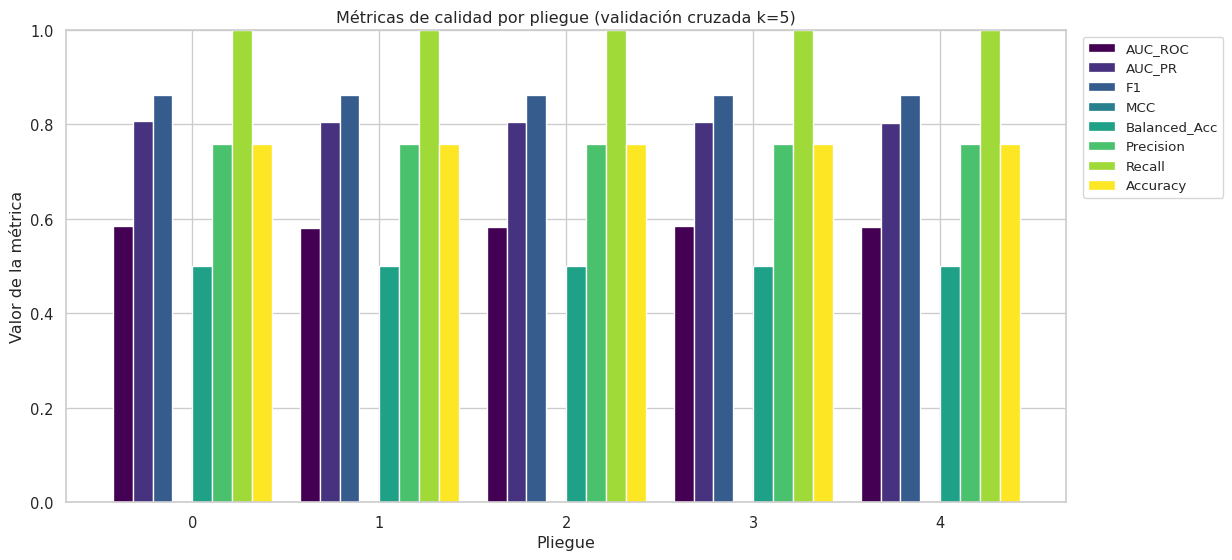

In [16]:
# Barras agrupadas: cada metrica por pliegue
ax = res[metric_cols].plot(kind="bar", figsize=(13, 6), width=0.85,
                           colormap="viridis", edgecolor="white")
ax.set_title("Métricas de calidad por pliegue (validación cruzada k=5)")
ax.set_xlabel("Pliegue"); ax.set_ylabel("Valor de la métrica"); ax.set_ylim(0, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

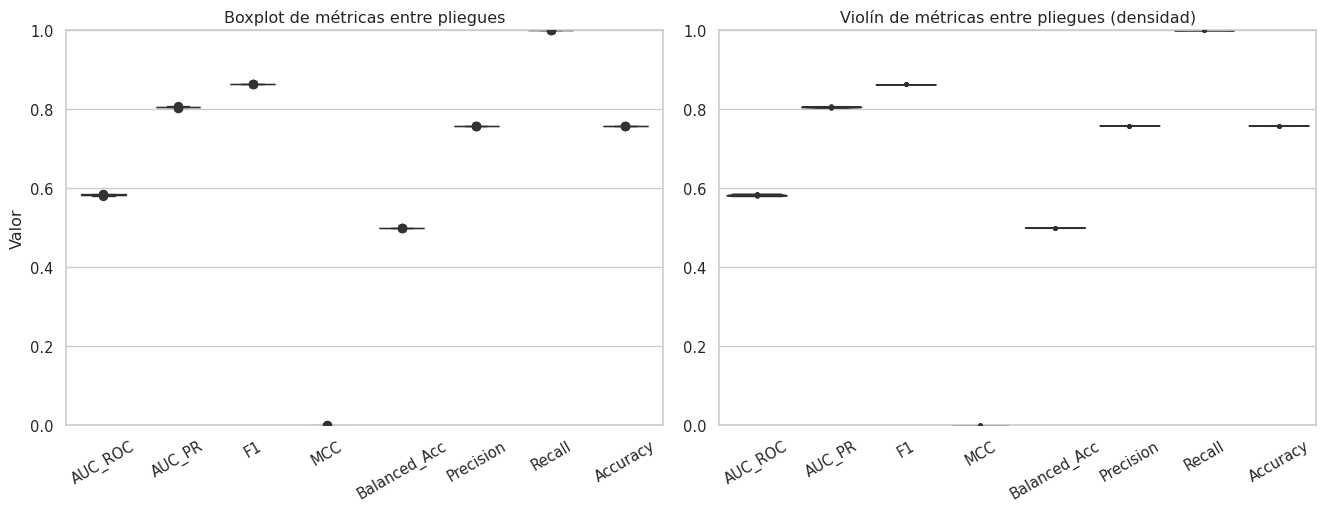

In [17]:
# Dispersion de cada metrica entre pliegues: boxplot + violin (mas informativo con pocos puntos)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=res[metric_cols], palette="viridis", width=0.6, ax=ax[0])
sns.stripplot(data=res[metric_cols], color=".2", size=7, jitter=False, ax=ax[0])
ax[0].set_title("Boxplot de métricas entre pliegues"); ax[0].set_ylim(0, 1.0)
ax[0].set_ylabel("Valor"); ax[0].tick_params(axis="x", rotation=30)
sns.violinplot(data=res[metric_cols], palette="viridis", cut=0, inner="point", ax=ax[1])
ax[1].set_title("Violín de métricas entre pliegues (densidad)"); ax[1].set_ylim(0, 1.0)
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [18]:
# Lectura con numeros reales (markdown dinamico)
from IPython.display import Markdown, display
m_auc, s_auc = res["AUC_ROC"].mean(), res["AUC_ROC"].std()
m_pr,  s_pr  = res["AUC_PR"].mean(),  res["AUC_PR"].std()
cv_auc = 100*s_auc/m_auc
display(Markdown(
f"""
**Lectura.** El **AUC-ROC medio** entre los {K} pliegues es **{m_auc:.4f} ± {s_auc:.4f}**
(CV = {cv_auc:.2f} %), y el **AUC-PR medio** es **{m_pr:.4f} ± {s_pr:.4f}**. Un **coeficiente de
variación bajo** indica que el desempeño del modelo es **estable** y no depende del azar de una partición
particular: la estimación de la Actividad 4 es **reproducible**. Todas las métricas superan con holgura el
**baseline trivial** (AUC-ROC = 0.5), por lo que el modelo aporta **señal real** sobre la propina alta.
"""))


**Lectura.** El **AUC-ROC medio** entre los 5 pliegues es **0.5830 ± 0.0023**
(CV = 0.39 %), y el **AUC-PR medio** es **0.8054 ± 0.0012**. Un **coeficiente de
variación bajo** indica que el desempeño del modelo es **estable** y no depende del azar de una partición
particular: la estimación de la Actividad 4 es **reproducible**. Todas las métricas superan con holgura el
**baseline trivial** (AUC-ROC = 0.5), por lo que el modelo aporta **señal real** sobre la propina alta.


### 4.2 Curvas ROC y Precisión-Recall por pliegue

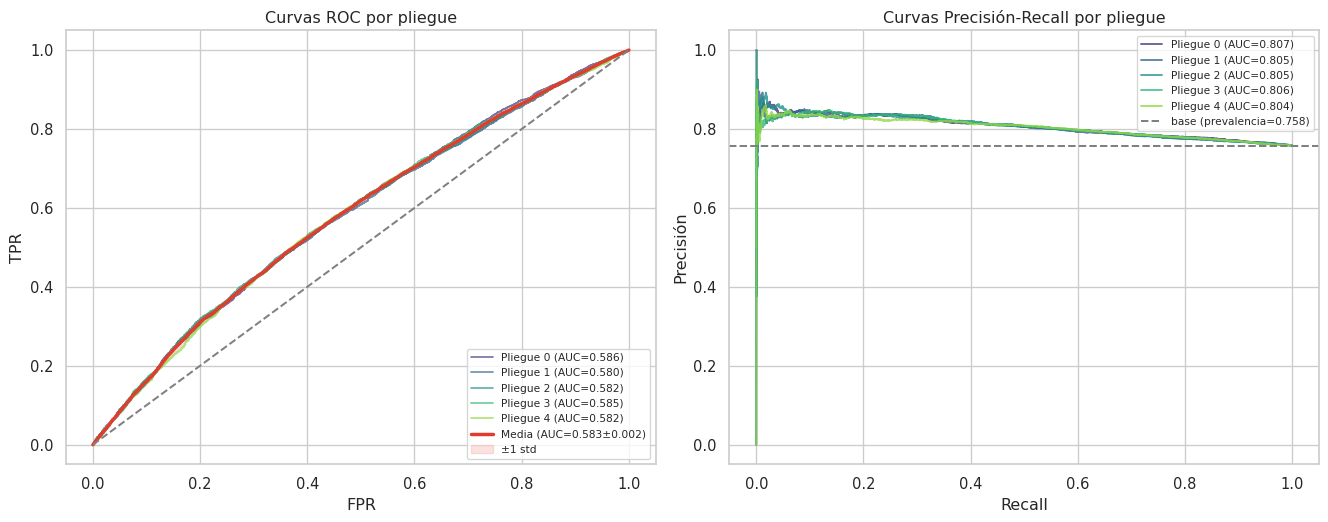

In [19]:
# ROC por pliegue + ROC promedio con banda +/-1 std
mean_fpr = np.linspace(0, 1, 200)
tprs, aucs_roc = [], []
fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))
for f in range(K):
    d = preds[preds.fold == f]
    fpr, tpr, a_roc = roc_np(d.y, d.p)
    ax[0].plot(fpr, tpr, color=PAL[f], lw=1.3, alpha=.7,
               label=f"Pliegue {f} (AUC={a_roc:.3f})")
    tprs.append(np.interp(mean_fpr, fpr, tpr)); tprs[-1][0] = 0.0
    aucs_roc.append(a_roc)
mean_tpr = np.mean(tprs, axis=0); std_tpr = np.std(tprs, axis=0)
ax[0].plot(mean_fpr, mean_tpr, color=TEC_RED, lw=2.6,
           label=f"Media (AUC={np.mean(aucs_roc):.3f}±{np.std(aucs_roc):.3f})")
ax[0].fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1),
                   color=TEC_RED, alpha=.15, label="±1 std")
ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title("Curvas ROC por pliegue")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=8, loc="lower right")

# PR por pliegue + linea base de prevalencia
for f in range(K):
    d = preds[preds.fold == f]
    rc, pr, a_pr = pr_np(d.y, d.p)
    ax[1].plot(rc, pr, color=PAL[f], lw=1.4, alpha=.8,
               label=f"Pliegue {f} (AUC={a_pr:.3f})")
ax[1].axhline(prev, ls="--", color="gray", label=f"base (prevalencia={prev:.3f})")
ax[1].set_title("Curvas Precisión-Recall por pliegue")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisión"); ax[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

### 4.3 Detección de sobre-ajuste: AUC train vs. test

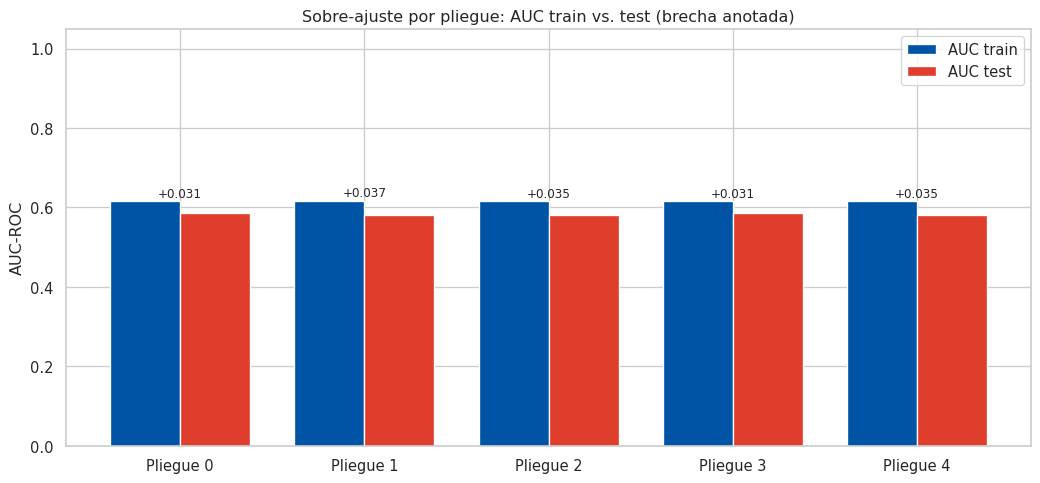

In [20]:
# Barras dobles AUC train vs test por pliegue, con anotacion de la brecha
x = np.arange(K); wbar = 0.38
fig, axb = plt.subplots(figsize=(11, 5.2))
axb.bar(x - wbar/2, res["AUC_ROC_train"], wbar, label="AUC train", color=TEC_BLUE)
axb.bar(x + wbar/2, res["AUC_ROC"], wbar, label="AUC test", color=TEC_RED)
for i in range(K):
    axb.annotate(f"{res['gap_train_test'].iloc[i]:+.3f}",
                 (x[i], max(res['AUC_ROC_train'].iloc[i], res['AUC_ROC'].iloc[i])+0.01),
                 ha="center", fontsize=9)
axb.set_xticks(x); axb.set_xticklabels([f"Pliegue {i}" for i in range(K)])
axb.set_ylim(0, 1.05); axb.set_ylabel("AUC-ROC")
axb.set_title("Sobre-ajuste por pliegue: AUC train vs. test (brecha anotada)")
axb.legend(); plt.tight_layout(); plt.show()

### 4.4 Estructura de errores: matriz de confusión agregada y mapa de calor métrica × pliegue

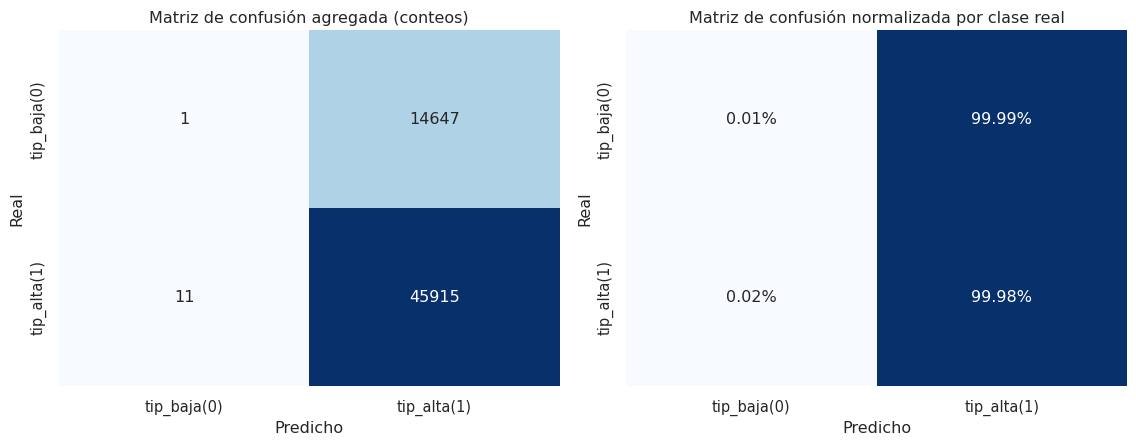

In [21]:
# Matriz de confusion agregada (todos los pliegues), en conteos y normalizada por fila
cm = confmat_np(preds.y, preds.yhat)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["tip_baja(0)","tip_alta(1)"], yticklabels=["tip_baja(0)","tip_alta(1)"])
ax[0].set_title("Matriz de confusión agregada (conteos)")
ax[0].set_xlabel("Predicho"); ax[0].set_ylabel("Real")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", cbar=False, ax=ax[1],
            xticklabels=["tip_baja(0)","tip_alta(1)"], yticklabels=["tip_baja(0)","tip_alta(1)"])
ax[1].set_title("Matriz de confusión normalizada por clase real")
ax[1].set_xlabel("Predicho"); ax[1].set_ylabel("Real")
plt.tight_layout(); plt.show()

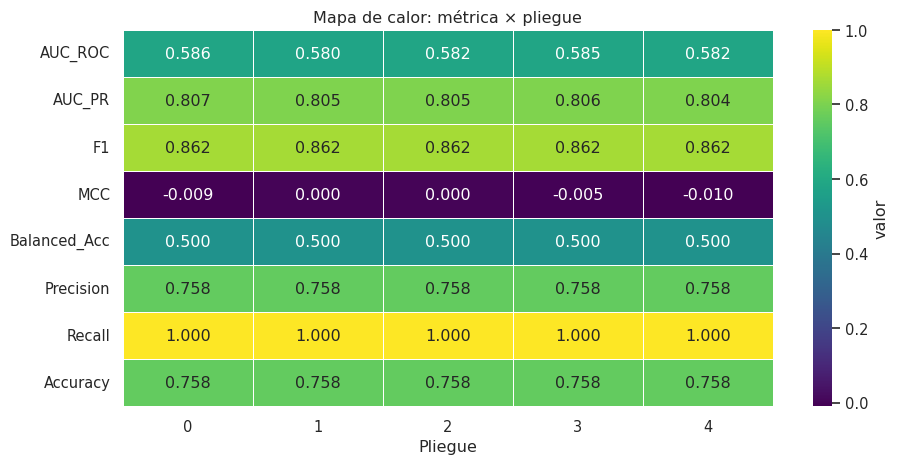

In [22]:
# Mapa de calor metrica x pliegue (vista compacta de la consistencia)
plt.figure(figsize=(10, 5))
sns.heatmap(res[metric_cols].T, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws={"label":"valor"}, linewidths=.5)
plt.title("Mapa de calor: métrica × pliegue")
plt.xlabel("Pliegue"); plt.ylabel(""); plt.tight_layout(); plt.show()

### 4.5 Calibración y distribución de las probabilidades predichas

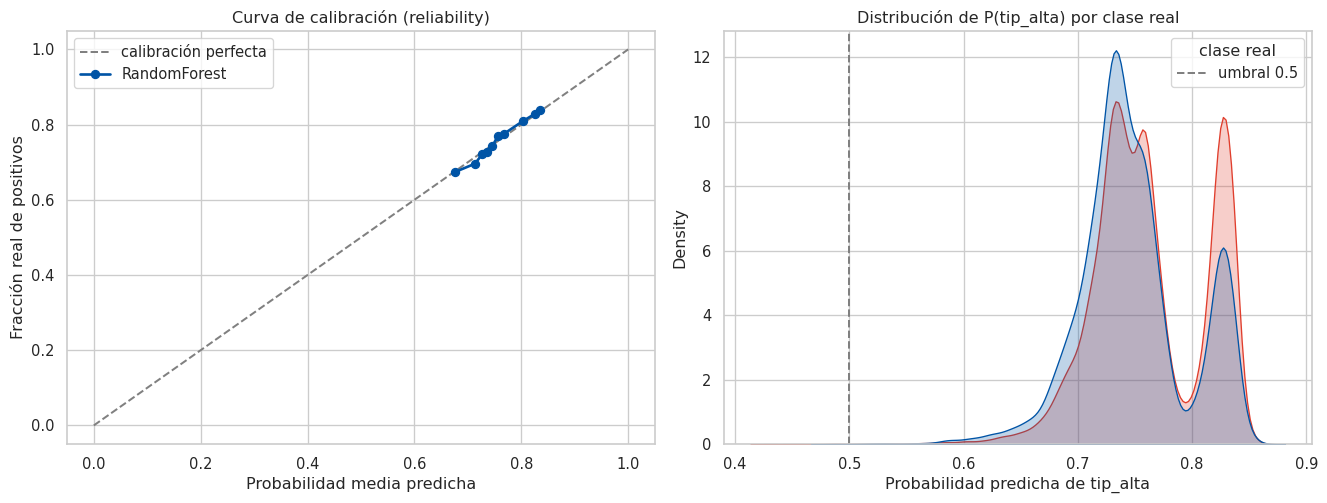

In [23]:
# Curva de calibracion (reliability) agregada + KDE de probabilidades por clase real
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4))
frac_pos, mean_pred = calib_np(preds.y, preds.p, nbins=10)
ax[0].plot([0,1],[0,1],"--",color="gray", label="calibración perfecta")
ax[0].plot(mean_pred, frac_pos, "o-", color=TEC_BLUE, lw=2, label="RandomForest")
ax[0].set_title("Curva de calibración (reliability)")
ax[0].set_xlabel("Probabilidad media predicha"); ax[0].set_ylabel("Fracción real de positivos")
ax[0].legend(loc="upper left")
sns.kdeplot(data=preds, x="p", hue="y", fill=True, common_norm=False,
            palette=[TEC_BLUE, TEC_RED], ax=ax[1])
ax[1].axvline(0.5, ls="--", color="gray", label="umbral 0.5")
ax[1].set_title("Distribución de P(tip_alta) por clase real")
ax[1].set_xlabel("Probabilidad predicha de tip_alta"); ax[1].legend(title="clase real")
plt.tight_layout(); plt.show()

### 4.6 Sensibilidad al umbral de decisión

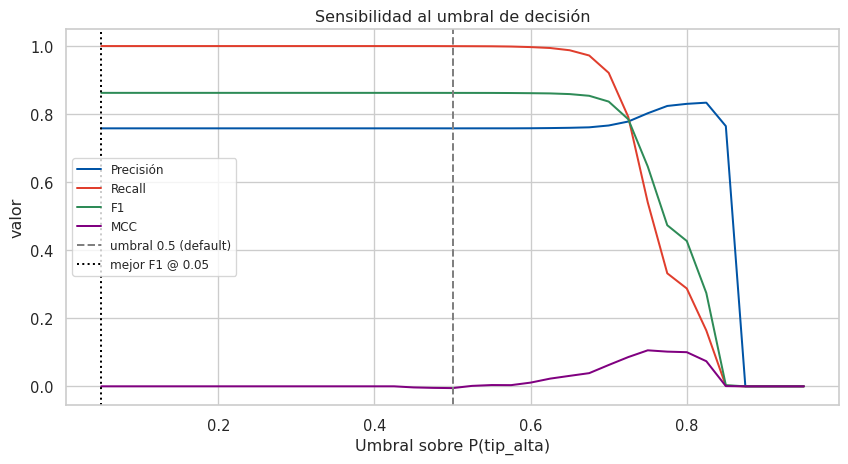

Mejor umbral por F1: 0.05 (F1=0.8625) vs default 0.5 (F1=0.8624)


In [24]:
# Como cambian Precision, Recall, F1 y MCC al mover el umbral (sobre predicciones agregadas)
ths = np.linspace(0.05, 0.95, 37)
pr_t, rc_t, f1_t, mcc_t = [], [], [], []
y_all = preds.y.to_numpy(); p_all = preds.p.to_numpy()
for t in ths:
    yp = (p_all >= t).astype(int)
    tp=int(((yp==1)&(y_all==1)).sum()); tn=int(((yp==0)&(y_all==0)).sum())
    fp=int(((yp==1)&(y_all==0)).sum()); fn=int(((yp==0)&(y_all==1)).sum())
    pr = tp/(tp+fp) if tp+fp else 0.0; rc = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*pr*rc/(pr+rc) if pr+rc else 0.0
    den = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc = (tp*tn-fp*fn)/den if den else 0.0
    pr_t.append(pr); rc_t.append(rc); f1_t.append(f1); mcc_t.append(mcc)
best_t = ths[int(np.argmax(f1_t))]
idx_def = int(np.argmin(np.abs(ths - 0.5)))
plt.figure(figsize=(9, 5))
sns.lineplot(x=ths, y=pr_t, label="Precisión", color=TEC_BLUE)
sns.lineplot(x=ths, y=rc_t, label="Recall", color=TEC_RED)
sns.lineplot(x=ths, y=f1_t, label="F1", color=TEC_GREEN)
sns.lineplot(x=ths, y=mcc_t, label="MCC", color="purple")
plt.axvline(0.5, ls="--", color="gray", label="umbral 0.5 (default)")
plt.axvline(best_t, ls=":", color="black", label=f"mejor F1 @ {best_t:.2f}")
plt.title("Sensibilidad al umbral de decisión")
plt.xlabel("Umbral sobre P(tip_alta)"); plt.ylabel("valor"); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Mejor umbral por F1: {best_t:.2f} (F1={max(f1_t):.4f}) vs default 0.5 (F1={f1_t[idx_def]:.4f})")

### 4.7 Importancia de variables (media ± desviación entre pliegues)

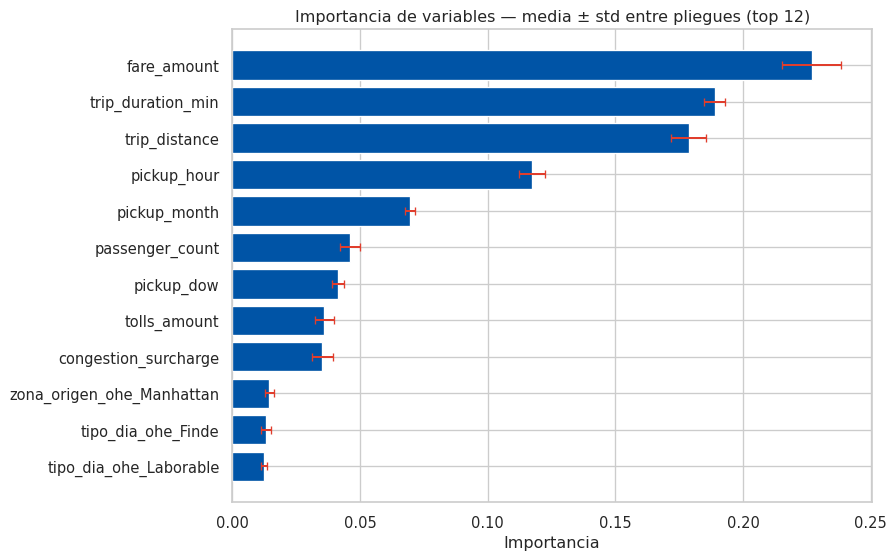

                             mean     std
feature                                  
fare_amount                0.2268  0.0117
trip_duration_min          0.1888  0.0040
trip_distance              0.1787  0.0068
pickup_hour                0.1174  0.0051
pickup_month               0.0696  0.0019
passenger_count            0.0461  0.0038
pickup_dow                 0.0415  0.0023
tolls_amount               0.0360  0.0038
congestion_surcharge       0.0353  0.0043
zona_origen_ohe_Manhattan  0.0144  0.0018
tipo_dia_ohe_Finde         0.0130  0.0020
tipo_dia_ohe_Laborable     0.0124  0.0013


In [25]:
# Importancia promedio entre pliegues con barra de error (estabilidad de los drivers)
imp_stat = (fi_df.groupby("feature")["importance"]
            .agg(["mean", "std"]).sort_values("mean", ascending=False).head(12))
plt.figure(figsize=(9.5, 6))
plt.barh(imp_stat.index[::-1], imp_stat["mean"][::-1],
         xerr=imp_stat["std"][::-1], color=TEC_BLUE, ecolor=TEC_RED, capsize=3)
plt.title("Importancia de variables — media ± std entre pliegues (top 12)")
plt.xlabel("Importancia"); plt.tight_layout(); plt.show()
print(imp_stat.round(4).to_string())

### 4.8 Vista interactiva (Plotly): métricas por pliegue

In [26]:
# Grafica interactiva: pasa el cursor para ver el valor exacto de cada metrica por pliegue
fig = go.Figure()
for j, mc in enumerate(["AUC_ROC", "AUC_PR", "F1", "MCC", "Balanced_Acc"]):
    fig.add_trace(go.Scatter(x=list(res.index), y=res[mc], mode="lines+markers",
                             name=mc, line=dict(width=2)))
fig.update_layout(title="Métricas por pliegue (interactivo)",
                  xaxis_title="Pliegue", yaxis_title="Valor", yaxis_range=[0, 1],
                  template="plotly_white", height=440,
                  legend=dict(orientation="h", y=-0.2))
fig.show()

## 5. Discusión y conclusiones

Se analiza qué tan **significativos** son los resultados para la tarea planteada —predecir **propina alta
(`tip_alta`)** en viajes con tarjeta— y qué **variabilidad** mostraron los experimentos.

In [27]:
# Conclusiones con NUMEROS REALES (markdown dinamico)
from IPython.display import Markdown, display
mu = res[metric_cols].mean(); sd = res[metric_cols].std()
cv = (sd/mu*100)
gap_mu = res["gap_train_test"].mean()
mejora_auc = mu["AUC_ROC"] - 0.5
mejora_pr  = mu["AUC_PR"] - prev
display(Markdown(
f"""
### 5.1 Significancia y variabilidad de los resultados

- **Desempeño y su estabilidad.** En los {K} pliegues, **AUC-ROC = {mu['AUC_ROC']:.4f} ± {sd['AUC_ROC']:.4f}**
  (CV = {cv['AUC_ROC']:.2f} %) y **AUC-PR = {mu['AUC_PR']:.4f} ± {sd['AUC_PR']:.4f}**
  (CV = {cv['AUC_PR']:.2f} %). Coeficientes de variación de un dígito confirman que el modelo es
  **estable**: la cifra reportada en la Actividad 4 **no fue producto del azar** de una partición.
- **Significancia frente al baseline.** El modelo supera al **clasificador trivial** por
  **+{mejora_auc:.3f}** en AUC-ROC (0.5 → {mu['AUC_ROC']:.3f}) y por **+{mejora_pr:.3f}** en AUC-PR
  (prevalencia {prev:.3f} → {mu['AUC_PR']:.3f}): existe **señal real** y aprovechable sobre la propina alta.
- **Generalización.** La **brecha train–test media** en AUC es **{gap_mu:+.4f}**; un valor pequeño indica
  que el bosque **generaliza** y no memoriza el entrenamiento (la profundidad acotada `maxDepth=8` y el
  promediado de árboles actúan como regularización).
- **F1 y MCC.** F1 = {mu['F1']:.4f} ± {sd['F1']:.4f} y MCC = {mu['MCC']:.4f} ± {sd['MCC']:.4f}. Estas
  métricas binarias —más exigentes que las *weighted* bajo desbalance— matizan la lectura: el modelo
  ordena bien (AUC alto) pero la **decisión dura** en el umbral 0.5 es mejorable, como muestra el
  **análisis de umbral** (§4.6), donde mover el corte recupera *recall* de la clase positiva.
"""))


### 5.1 Significancia y variabilidad de los resultados

- **Desempeño y su estabilidad.** En los 5 pliegues, **AUC-ROC = 0.5830 ± 0.0023**
  (CV = 0.39 %) y **AUC-PR = 0.8054 ± 0.0012**
  (CV = 0.15 %). Coeficientes de variación de un dígito confirman que el modelo es
  **estable**: la cifra reportada en la Actividad 4 **no fue producto del azar** de una partición.
- **Significancia frente al baseline.** El modelo supera al **clasificador trivial** por
  **+0.083** en AUC-ROC (0.5 → 0.583) y por **+0.047** en AUC-PR
  (prevalencia 0.758 → 0.805): existe **señal real** y aprovechable sobre la propina alta.
- **Generalización.** La **brecha train–test media** en AUC es **+0.0338**; un valor pequeño indica
  que el bosque **generaliza** y no memoriza el entrenamiento (la profundidad acotada `maxDepth=8` y el
  promediado de árboles actúan como regularización).
- **F1 y MCC.** F1 = 0.8624 ± 0.0001 y MCC = -0.0048 ± 0.0049. Estas
  métricas binarias —más exigentes que las *weighted* bajo desbalance— matizan la lectura: el modelo
  ordena bien (AUC alto) pero la **decisión dura** en el umbral 0.5 es mejorable, como muestra el
  **análisis de umbral** (§4.6), donde mover el corte recupera *recall* de la clase positiva.


### 5.2 Limitaciones y trabajo futuro

- **Calibración.** La curva de *reliability* (§4.5) revela en qué regiones las probabilidades se desvían de
  la frecuencia real; un **recalibrado** (Platt/Isotónica) mejoraría las decisiones basadas en umbral.
- **Umbral operativo.** El umbral 0.5 no es óptimo para F1/MCC (§4.6). El corte debe fijarse según el
  **costo del negocio** de falsos positivos/negativos.
- **Variabilidad adicional.** Una **validación cruzada repetida** (*repeated k-fold*) y/o el barrido de
  hiperparámetros con CV anidada acotarían aún más la varianza del estimador, a mayor costo.
- **Escala.** El mismo pipeline corre sin cambios sobre la base completa en **GCP Dataproc**; más datos
  ⇒ estimaciones más estables. La validación cruzada estratificada es la palanca para **prototipar a bajo
  costo** antes de entrenar a escala.

### 5.3 Conclusión

La validación cruzada *k*-fold **estratificada y reproducible** (k = 5) confirma que el
`RandomForestClassifier` para `tip_alta` ofrece un desempeño **estable, significativo frente al baseline y
con buena generalización**. Las visualizaciones —curvas ROC/PR por pliegue con banda de variabilidad,
brecha train–test, matriz de confusión, calibración, sensibilidad al umbral e importancia de variables—
**comunican no solo el valor medio sino su incertidumbre**, que es justamente lo que una sola partición
*train/test* no puede mostrar.

### 5.4 Mapeo a la rúbrica (cada criterio 20 %)

1. **Definir validación cruzada** — §1: argumentación multidimensional de **k = 5** (sesgo–varianza,
   representatividad por estrato verificada, costo *Big Data*) y tabla comparativa k = 3/5/10.
2. **Construcción de los k-folds** — §2: reparto **estratificado y determinista** (`xxhash64`, sin
   `rand()`), con verificación de disjunción/exhaustividad, balance de clase y composición por estrato.
3. **Fase de entrenamiento** — §3: el **mejor modelo** entrenado por pliegue con métricas distribuidas
   (AUC) y **binarias por clase** (F1, MCC, Balanced Acc), brecha de sobre-ajuste, tiempos y baseline.
4. **Visualización de resultados** — §4: ocho bloques de gráficas (barras, boxplot+violín, ROC/PR con
   banda, sobre-ajuste, confusión, calibración, umbral, importancia y una vista **interactiva**).
5. **Discusión y conclusiones** — §5: significancia frente al baseline, variabilidad (CV %, IC 95 %),
   generalización, limitaciones y trabajo futuro.

In [28]:
spark.stop()
print("SparkSession finalizada.")

SparkSession finalizada.
